In [ ]:
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.0-py2.py3-none-any.whl size=317425345 sha256=57a5e7100eef082639071623fbbc17ee752492614f7531d4d27c6b9d186409c2
  Stored in directory: /root/.cache/pip/wheels/41/4e/10/c2cf2467f71c678cfc8a6b9ac9241e5e44a01940da8fbb17fc
Successfully built pyspark


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark.sql import *
from keras.utils.np_utils import to_categorical


In [ ]:
spark = SparkSession.builder\
    .master("local[*]")\
    .config("spark.sql.repl.eagerEval.enabled", "true") \
    .config("spark.driver.memory", "30g") \
    .getOrCreate()
sc = spark.sparkContext
spark
#SparkSession.builder: Starts the process of creating a SparkSession
#eager evaluation means that spark immediately runs transformations and actions on RDD
#master("local[*]"): Specifies the Spark master URL to run the application locally using all available CPU cores
#SparkContext represents the connection to the Spark cluster.

In [ ]:
!wget https://archive.org/download/intel-dataset_20230726_0457/Intel__Dataset.zip
!unzip -o -q Intel__Dataset


--2024-02-12 07:42:18--  https://archive.org/download/intel-dataset_20230726_0457/Intel__Dataset.zip
Resolving archive.org (archive.org)... 207.241.224.2
Connecting to archive.org (archive.org)|207.241.224.2|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ia802706.us.archive.org/22/items/intel-dataset_20230726_0457/Intel__Dataset.zip [following]
--2024-02-12 07:42:18--  https://ia802706.us.archive.org/22/items/intel-dataset_20230726_0457/Intel__Dataset.zip
Resolving ia802706.us.archive.org (ia802706.us.archive.org)... 207.241.228.246
Connecting to ia802706.us.archive.org (ia802706.us.archive.org)|207.241.228.246|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 58300783 (56M) [application/zip]
Saving to: ‘Intel__Dataset.zip’

Intel__Dataset.zip  100%[===================>]  55.60M   289KB/s    in 4m 2s   

2024-02-12 07:46:21 (235 KB/s) - ‘Intel__Dataset.zip’ saved [58300783/58300783]



In [ ]:
data = 'Intel__Dataset'
train_data = f'{data}/seg_train'
test_data = f'{data}/seg_test'

In [ ]:
def activation(x, f):
    return f(x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    sig = sigmoid(x)
    return sig * (1 - sig)

def apply_sigmoid2(x):
    image_data, forward1, activation1, forward2, label = x
    label_pred = activation(forward2, sigmoid)
    print(label_pred.shape)
    return (image_data, forward1, activation1, forward2, label_pred, label)

In [ ]:
from sklearn.metrics import multilabel_confusion_matrix

# cost function
def get_error(prediction, actual):
    return 0.5 * np.sum(np.power(prediction - actual, 2))

# confusion matrix
def get_metrics(predicted, actual):
    return multilabel_confusion_matrix(actual, predicted)


In [ ]:
# derivatives
def get_error_b2(prediction, actual, y, y_):
    return (prediction - actual) * y_(y)

def get_error_w2(h, error_b2):
    return np.dot(h.T, error_b2)

def get_error_b1(h, error_b2, weights2, y_):
    return np.dot(error_b2, weights2.T) * y_(h)

def get_error_w1(x, error_b1):
    return np.dot(x.T, error_b1)

In [ ]:
# Feed Forward layer
def preforward(x, w, b):
    return np.dot(x, w) + b

# Prediction function
def predict(x, W1, B1, W2, B2):
    forward_op1 = preforward(x, W1, B1)
    activation_op1 = sigmoid(forward_op1)
    forward_op2 = preforward(activation_op1, W2, B2)
    prediction = sigmoid(forward_op2)
    return prediction

In [ ]:
b = 5
image_size = (150, 150)
seed = 120
image_size_linear = image_size[0] * image_size[1]

def get_train_images(data):

    return tf.keras.utils.image_dataset_from_directory(data, batch_size=b, image_size=image_size, seed=seed, subset = 'both', validation_split = 0.2)

def get_test_images(data):
    return tf.keras.utils.image_dataset_from_directory(data, batch_size=b, image_size=image_size, seed=seed)


In [ ]:
train_dataset = get_train_images(train_data)
test_dataset = get_test_images(test_data)

validation_dataset = train_dataset[1]
train_dataset = train_dataset[0]

Found 3069 files belonging to 2 classes.
Using 2456 files for training.
Using 613 files for validation.
Found 962 files belonging to 2 classes.


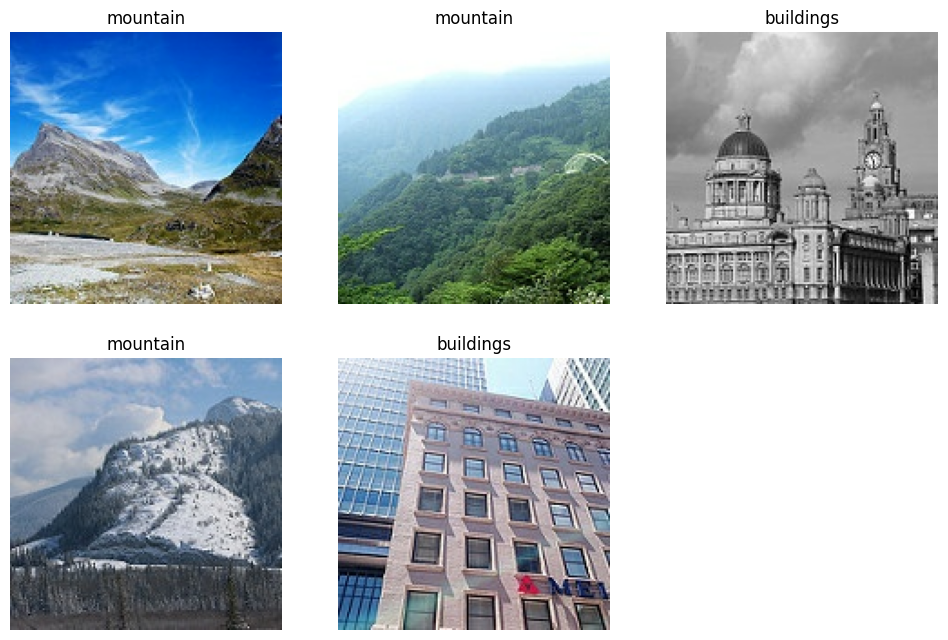

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from pyspark import SparkContext

# Check if a SparkContext already exists
if 'sc' not in globals():
    sc = SparkContext()

def flatten(images):
    return tf.reshape(images, (-1, image_size_linear))

def get_labels(labels):
    return to_categorical(labels, num_classes=len(class_labels), dtype=int)

def get_image_data(dataset):
    image_data = []
    for images, labels in dataset.as_numpy_iterator():
        flattened_images = flatten(images)
        labels = get_labels(labels)  # Convert labels to categorical format
        for image, label in zip(flattened_images, labels):
            k = image.numpy().reshape(1, image_size_linear)
            v = label
            image_data.append((k, v))
    return image_data

train_ds_numpy = train_ds.unbatch()  # Unbatch the dataset to process individual images
image_data = get_image_data(train_ds_numpy)

train_rdd = sc.parallelize(image_data)
train_rdd.take(5)


# Pre-Processing

In [ ]:
def image_preprocessing(image, label):
    image = tf.image.rgb_to_grayscale(image)
    image = tf.keras.layers.Rescaling(scale = 1. / 255)(image)
    return image, label
# Map function is used to apply the function to each element of these datasets in a parallelized manner
# transforming the images within them according to the specified preprocessing steps
train_ds = train_dataset.map(image_preprocessing)
val_ds = validation_dataset.map(image_preprocessing)
test_ds= test_dataset.map(image_preprocessing)

In [ ]:
#flattening the image according to image_size_linear that we initialized previously
def flatten(images):
    return images.reshape(-1, image_size_linear)
#encodes labels
def get_labels(label):
    return to_categorical([label], num_classes=len(class_labels), dtype=int)
#flattening each image,encoding labels,storing image,label in lists.
def get_image_data(dataset):
    image_data = []
    for images, labels in list(dataset.as_numpy_iterator()):
        for image, label in zip(flatten(images), labels):
            k = image.reshape(1, image_size_linear)
            v = get_labels(label).tolist()
            image_data.append((k, v))
    return image_data

#performing the function on every image
image_data = get_image_data(train_ds)
#converting train data to a RDD using sc.parallelize
train_rdd = sc.parallelize(image_data)
train_rdd.take(5)


[(array([[0.35811374, 0.35811374, 0.35811374, ..., 0.2543271 , 0.11316472,
          0.19943061]], dtype=float32),
  [[0, 1]]),
 (array([[0.6171628 , 0.6250052 , 0.6250052 , ..., 0.34031492, 0.3218812 ,
          0.3532506 ]], dtype=float32),
  [[1, 0]]),
 (array([[0.453773  , 0.4498518 , 0.44403335, ..., 0.15029256, 0.1256357 ,
          0.08989804]], dtype=float32),
  [[0, 1]]),
 (array([[0.8702585 , 0.83496785, 0.7932428 , ..., 0.02623373, 0.02623373,
          0.02231255]], dtype=float32),
  [[1, 0]]),
 (array([[0.47062278, 0.47062278, 0.4830024 , ..., 0.9450037 , 0.843053  ,
          0.9999001 ]], dtype=float32),
  [[0, 1]])]

In [ ]:
input_layer = image_size_linear

output_layer = len(class_labels)

In [ ]:
#apply perceptron law on x
def apply_forward1(x, weights1, bias1):
    image_data, label = x
    forward1 = preforward(image_data, weights1, bias1)
    return (image_data, forward1, label)

def apply_sigmoid1(x):
    image_data, forward1, label = x
    activation1 = activation(forward1, sigmoid)
    return (image_data, forward1, activation1, label)

def apply_forward2(x, weights2, bias2):
    image_data, forward1, activation1, label = x
    forward2 = preforward(activation1, weights2, bias2)
    return (image_data, forward1, activation1, forward2, label)

def apply_sigmoid2(x):
    image_data, forward1, activation1, forward2, label = x
    label_pred = activation(forward2, sigmoid)
    return (image_data, forward1, activation1, forward2, label_pred, label)

def apply_forward3(x, weights3, bias3):
    image_data, forward1, activation1, forward2, activation2, label = x
    forward3 = preforward(activation2, weights3, bias3)
    return (image_data, forward1, activation1, forward2, activation2, forward3, label)

def apply_sigmoid3(x):
    image_data, forward1, activation1, forward2, activation2, forward3, label = x
    label_pred = activation(forward3, sigmoid)
    return (image_data, forward1, activation1, forward2, activation2, forward3, label_pred, label)

def estimate_error_b2(x):
    image_data, forward1, activation1, forward2, label_pred, label = x
    error = get_error(label_pred, label)
    error_b2 = get_error_b2(label_pred, label, forward2, sigmoid_derivative)
    correct_prediction = int(np.argmax(label_pred) == np.argmax(label))
    return (image_data, forward1, activation1, error, error_b2, correct_prediction)

def estimate_error_w2(x):
    image_data, forward1, activation1, error, error_b2, correct_prediction = x
    error_w2 = get_error_w2(activation1, error_b2)
    return (image_data, forward1, error, error_b2, error_w2, correct_prediction)

def estimate_error_b1(x, weights2):
    image_data, forward1, error, error_b2, error_w2, correct_prediction = x
    error_b1 = get_error_b1(forward1,  error_b2, weights2, sigmoid_derivative)
    return (image_data, error, error_b2, error_w2, error_b1, correct_prediction)

def estimate_error_w1(x):
    image_data, error, error_b2, error_w2, error_b1, correct_prediction = x
    error_w1 = get_error_w1(image_data, error_b1)
    return (error, error_b2, error_w2, error_b1, error_w1, correct_prediction, 1)

def update_weights_and_bias(learning_rate, weights1, weights2, bias1, bias2, error_b2, error_w2, error_b1, error_w1, num_imgs):
    new_bias2 = bias2 - (learning_rate * (error_b2 / num_imgs))
    new_weight2 = weights2 - (learning_rate * (error_w2 / num_imgs))
    new_bias1 = bias1 - (learning_rate * (error_b1 / num_imgs))
    new_weight1 = weights1 - (learning_rate * (error_w1 / num_imgs))

    return (new_weight1, new_bias1, new_weight2, new_bias2)

def reduce_util(x, y):
    x_error, b2_x_err, w2_x_err, b1_x_err, w1_x_err, correct_prediction_x, count_x = x
    y_error, b2_y_err, w2_y_err, b1_y_err, w1_y_err, correct_prediction_y, count_y = y
    error = x_error + y_error
    error_b2 = b2_x_err + b2_y_err
    error_w2 = w2_x_err + w2_y_err
    error_b1 = b1_x_err + b1_y_err
    error_w1 = w1_x_err + w1_y_err
    correct_predictions = correct_prediction_x + correct_prediction_y
    num_imgs = count_x + count_y
    return (error, error_b2, error_w2, error_b1, error_w1, correct_predictions, num_imgs)

def get_random_weights(start, end, initial_bias):
  return np.random.rand(start, end) - initial_bias


### Model training

In [ ]:
def fit(itr, learning_rate, hidden_layers):
  #initializing biases and weights
  initial_bias = 0.5
  weights1 = get_random_weights(input_layer, hidden_layers, initial_bias)
  weights2 = get_random_weights(hidden_layers, output_layer, initial_bias)
  bias1 = get_random_weights(1, hidden_layers, initial_bias)
  bias2 = get_random_weights(1, output_layer, initial_bias)
  print(f"Hidden layers={hidden_layers}, Learning Rate={learning_rate}, Max Iterations={itr}")
  accuracies = []
  errors = []
  for i in range(itr):
    #Training Pipeline
    # \ means continuation
      output = train_rdd \
          .map(lambda x: apply_forward1(x, weights1, bias1)) \
          .map(lambda x: apply_sigmoid1(x)) \
          .map(lambda x: apply_forward2(x, weights2, bias2)) \
          .map(lambda x: apply_sigmoid2(x)) \
          .map(lambda x: estimate_error_b2(x)) \
          .map(lambda x: estimate_error_w2(x)) \
          .map(lambda x: estimate_error_b1(x, weights2)) \
          .map(lambda x: estimate_error_w1(x)) \
          .reduce(reduce_util)
      #based on reduce.util output[5] is the no of correct predictions
      #output[6] is the no of images
      iteration_accuracy = output[5] / output[6]
      #output[0] is error
      iteration_error = output[0] / output[6]
      accuracies.append(iteration_accuracy)
      errors.append(iteration_error)
      weights1, bias1, weights2, bias2 = update_weights_and_bias(learning_rate, weights1, weights2, bias1, bias2, output[1], output[2], output[3], output[4], output[6])
  print(f"number of Iterations: {itr} | Accuracy: {accuracies[-1]:.4f} | Error: {errors[-1]:.4f}")
  return weights1, weights2, bias1, bias2, accuracies, errors

In [ ]:
test_image_data = get_image_data(test_dataset)
test_rdd = sc.parallelize(test_image_data)

In [ ]:
def prediction_mapper(x, weights1, bias1, weights2, bias2):
  prediction = predict(x[0], weights1, bias1, weights2, bias2)
#calculating error between prediction and actual label
  error = get_error(prediction, x[1])
#computes whether the model's prediction matches the ground truth label for a given data point
#returns 1 for correct predictions and 0 for incorrect predictions
  correct_prediction = int(np.argmax(prediction) == np.argmax(x[1]))
  return (correct_prediction, error, 1)
#aggregating correct_prediction,error and 1's
def prediction_reducer(x, y):
    return (x[0] + y[0], x[1] + y[1], x[2] + y[2])

In [ ]:
iterations = [30]
learning_rates = [0.2, 0.3]
hidden_layers = [ 128]
i = 0
model_params = []
train_accuracies_list = []
train_errors_list = []
for hidden_layer in hidden_layers:
  for lr in learning_rates:
    i+=1
    for itr in iterations:
      # training phase
      w1, w2, bias1, bias2, train_accuracy, train_error = fit(itr, lr, hidden_layer)
      # prediction phase
      #implement prediction_mapper on data and subsequently aggregating data using prediction_reducer
      res = test_rdd.map(lambda x: prediction_mapper(x, w1, bias1, w2, bias2)).reduce(prediction_reducer)
      total_error = res[1]
      correct_predictions = res[0]
      count = res[2]
      train_accuracies_list.append(train_accuracy)
      train_errors_list.append(train_error)
      test_error = total_error / count
      test_accuracy = correct_predictions / count
      model_params.append({
          'max_iterations': itr,
          'rate': lr,
          'hidden_layers': hidden_layer,
          'train_loss': np.min(train_error),
          'train_accuracy': np.max(train_accuracy),
          'test_loss': test_error,
          'test_accuracy': test_accuracy
      })

Hidden layers=128, Learning Rate=0.2, Max Iterations=30
number of Iterations: 30 | Accuracy: 0.6209 | Error: 0.2409
Hidden layers=128, Learning Rate=0.3, Max Iterations=30
number of Iterations: 30 | Accuracy: 0.7032 | Error: 0.2167
